<a href="https://colab.research.google.com/github/keshariujjwal51/Ujjwal/blob/main/Assigement2_Celebal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025 (1).csv')
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nDescribe:")
display(df.describe())

Shape: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Ch

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [5]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Missing Values
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows
0


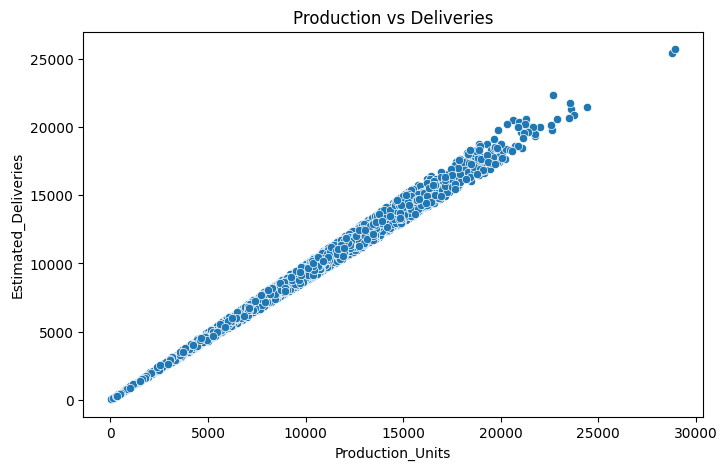

In [6]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Production_Units'],
    y=df['Estimated_Deliveries']
)

plt.title("Production vs Deliveries")

plt.show()

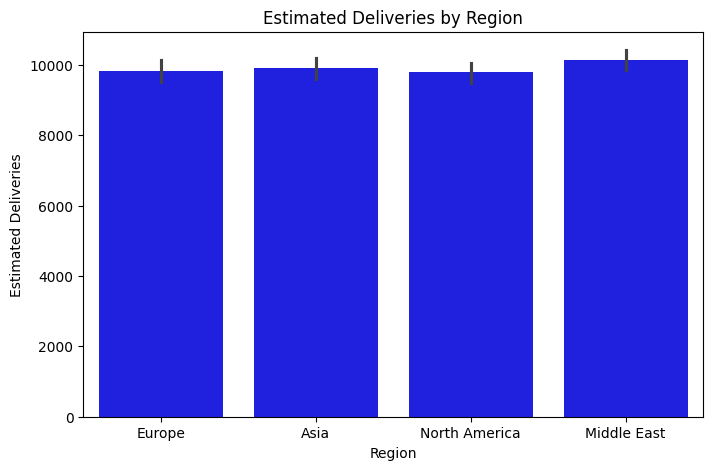

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Region',
    y='Estimated_Deliveries',
    color = 'blue'
)

plt.title("Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")

plt.show()

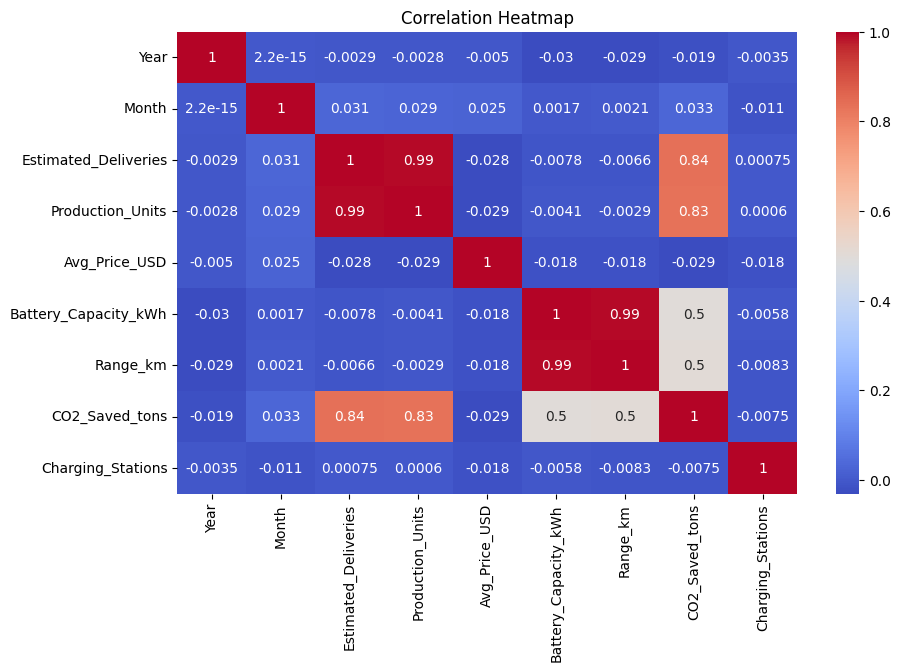

In [8]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

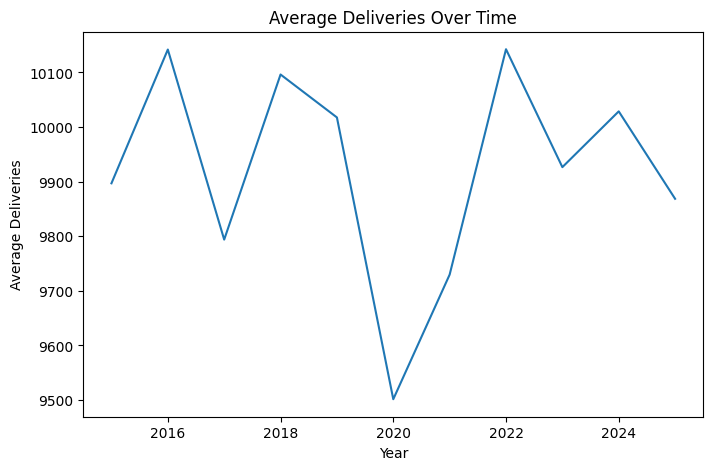

In [9]:
trend = df.groupby('Year')['Estimated_Deliveries'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=trend,
    x='Year',
    y='Estimated_Deliveries'
)

plt.title("Average Deliveries Over Time")
plt.xlabel("Year")
plt.ylabel("Average Deliveries")

plt.show()

In [11]:
X = df.drop('Estimated_Deliveries', axis=1)

y = df['Estimated_Deliveries']

print(X.shape)

print(y.shape)

(2640, 11)
(2640,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(2112, 11)
(528, 11)


In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# Identify categorical columns from the original DataFrame df
categorical_features = ['Region', 'Model', 'Source_Type']

# Apply one-hot encoding to the entire X dataset
# X and y are assumed to be globally available from previous cells
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Re-split the encoded data into training and testing sets
# This redefines X_train, X_test, y_train, y_test with numerical features
# Use the same test_size and random_state as in the original split for consistency
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Fit the model with the now numerical training data
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [15]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 7363.81  9358.95  8930.55  9397.23  8768.84 11768.04 14033.76 13937.83
 10149.59  7902.08]


In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test,y_pred)
)

r2 = r2_score(y_test,y_pred)

print(mae)
print(rmse)
print(r2)

321.2271022727273
405.3520800898201
0.9889771143991034


In [17]:
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)

df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna(
    df['Deliveries_Lag1'].mean()
)
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(3)
    .mean()
)

df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(
    df['Rolling_Mean_3'].mean()
)
df[['Estimated_Deliveries', 'Deliveries_Lag1']].head()
print(df[['Estimated_Deliveries',
          'Deliveries_Lag1',
          'Rolling_Mean_3']].head())

   Estimated_Deliveries  Deliveries_Lag1  Rolling_Mean_3
0                 17646      9924.959454     9923.677407
1                  3797     17646.000000     9923.677407
2                  8411      3797.000000     9951.333333
3                  6555      8411.000000     6254.333333
4                 12374      6555.000000     9113.333333


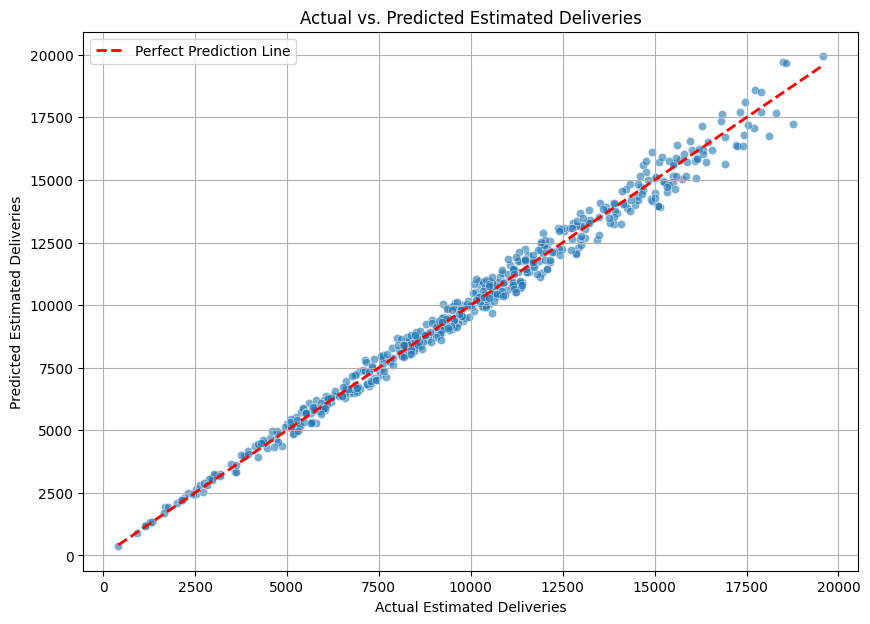

In [18]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Estimated Deliveries')
plt.ylabel('Predicted Estimated Deliveries')
plt.title('Actual vs. Predicted Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[50,100],
    'max_depth':[5,10,None]
}

rf = RandomForestRegressor(
    random_state=42
)

grid = GridSearchCV(
    rf,
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, None], 'n_estimators': [50, 100]},
             scoring='r2')

In [20]:
print(grid.best_params_)

{'max_depth': None, 'n_estimators': 100}


In [21]:
best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test)

print(
    r2_score(y_test,rf_pred)
)

0.9889771143991034


Future Predictions

In [23]:
current_max_year = df['Year'].max()
future_years = range(current_max_year + 1, current_max_year + 6) # Predict for 5 future years (2026-2030)
future_months = range(1, 13)
unique_regions = df['Region'].unique()
unique_models = df['Model'].unique()
unique_source_types = df['Source_Type'].unique()

from itertools import product
future_data_combinations = list(product(future_years, future_months, unique_regions, unique_models, unique_source_types))

future_df_input = pd.DataFrame(future_data_combinations, columns=['Year', 'Month', 'Region', 'Model', 'Source_Type'])

numeric_cols_for_mean = ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
for col in numeric_cols_for_mean:
    # Introduce a small random variation around the mean for future predictions
    # This makes the future predictions non-constant.
    # Using a uniform distribution from -5% to +5% of the mean.
    future_df_input[col] = df[col].mean() * (1 + np.random.uniform(-0.05, 0.05, len(future_df_input)))

future_X_encoded = pd.get_dummies(future_df_input, columns=categorical_features, drop_first=True)

# Align columns of future_X_encoded with the columns used for training (X_encoded.columns)
train_cols = X_encoded.columns

# Add missing columns to future_X_encoded and fill with 0
missing_cols_in_future = set(train_cols) - set(future_X_encoded.columns)
for col in missing_cols_in_future:
    future_X_encoded[col] = 0

# Drop extra columns from future_X_encoded that were not in the training set
extra_cols_in_future = set(future_X_encoded.columns) - set(train_cols)
if extra_cols_in_future:
    future_X_encoded = future_X_encoded.drop(columns=list(extra_cols_in_future))

# Ensure the order of columns matches the training set
future_X_encoded = future_X_encoded[train_cols]

future_predictions = best_rf.predict(future_X_encoded)

future_df_input['Predicted_Estimated_Deliveries'] = future_predictions

print("First 5 rows of Future Predictions:")
display(future_df_input.head())

#display average predictions per year
average_yearly_predictions = future_df_input.groupby('Year')['Predicted_Estimated_Deliveries'].mean().reset_index()
print("\nAverage Yearly Predicted Deliveries:")
display(average_yearly_predictions)

First 5 rows of Future Predictions:


,Year,Month,Region,Model,Source_Type,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Predicted_Estimated_Deliveries
0,2026,1,Europe,Model S,Interpolated (Month),10560.969094,82627.262583,87.632513,515.160461,720.613513,9095.585703,9607.02
1,2026,1,Europe,Model S,Official (Quarter),10936.686704,87575.430366,84.664051,501.860699,742.402529,8607.975875,10303.79
2,2026,1,Europe,Model S,Estimated (Region),10244.402295,85269.486753,89.745677,492.421518,755.514297,8549.679284,9546.69
3,2026,1,Europe,Model X,Interpolated (Month),10541.916278,84756.205043,90.777820,480.573963,776.397402,9092.384977,9849.00
4,2026,1,Europe,Model X,Official (Quarter),10490.765004,84533.581571,88.140143,510.793449,774.442366,8884.897381,9644.56



Average Yearly Predicted Deliveries:


,Year,Predicted_Estimated_Deliveries
0,2026,9906.417153
1,2027,9878.184222
2,2028,9900.045264
3,2029,9911.741833
4,2030,9886.634819


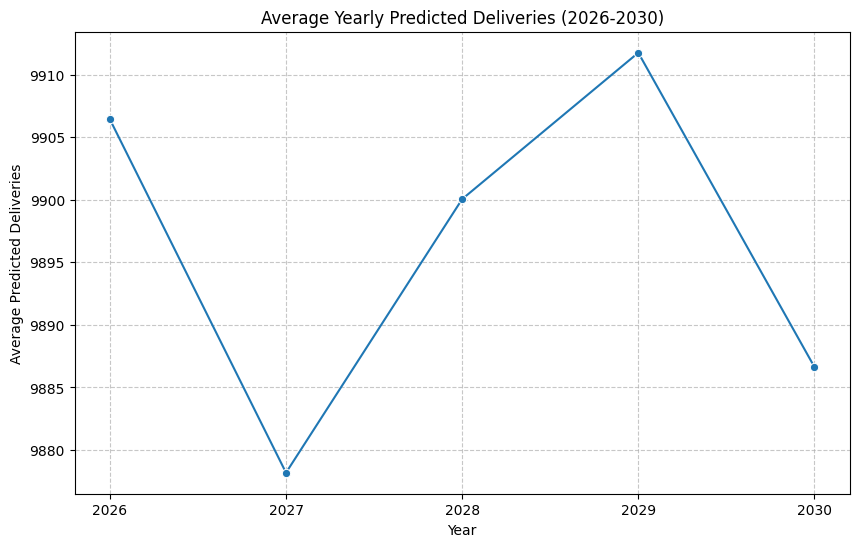

In [24]:
plt.figure(figsize=(10, 6)) # Increased figure size to accommodate more years
sns.lineplot(
    data=average_yearly_predictions,
    x='Year',
    y='Predicted_Estimated_Deliveries',
    marker='o' # Add markers for clarity
)
plt.title('Average Yearly Predicted Deliveries (2026-2030)') # Updated title
plt.xlabel('Year')
plt.ylabel('Average Predicted Deliveries')
plt.xticks(average_yearly_predictions['Year']) # Ensure all years are shown on x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()